# Nighttime Lights Trends in Ethiopia

This notebook provides an analysis on the temporal and spatial patterns of nighttime lights trends in Ethiopia from 2012 to 2024. The analysis includes visualizations of nighttime lights trends at national and regional levels.

## Methodology

We created a time series of weekly radiance using NASA's Black Marble data which involves several steps, including data acquisition, pre-processing, zonal statistics calculation, and time series generation. The zonal statistics of the aggregated sum of nighttime lights is used to make inferences. 

This notebook uses NASA's Collection-2.

In [2]:
import os
from datetime import datetime

# import colorcet as cc
import folium
import geopandas
import pandas as pd
import altair as alt

# Enable Altair data transformer for larger datasets
alt.data_transformers.enable('default', max_rows=None)

# from blackmarble.extract import bm_extract

%load_ext autoreload
%autoreload 2

**Region of Interest**

In [3]:
ethiopia_adm1 = geopandas.read_file(
    "../../data/boundaries/Region_14/Regions_14.shp"
)
ethiopia_adm2 = geopandas.read_file(
    "../../boundaries/adm2_mapped.geojson"
)

ethiopia_adm3 = geopandas.read_file(
    "../../boundaries/adm3_mapped.geojson"
)
# ethiopia.explore()

In [4]:
import numpy as np

def get_annual_percent_change(
    df, group_columns=["ADM1_EN"], baseline_year="PY", column="ntl_sum"
):
    df = df.copy()
    df["year"] = df["date"].dt.year
    baseline_column = f"baseline_{column}_{baseline_year}"
    column_name = f"percent_change_{column}_{baseline_year}"

    if isinstance(baseline_year, int):  # Fixed baseline year case
        baseline_df = (
            df[df["year"] == baseline_year]
            .groupby(group_columns)[column]
            .mean()
            .reset_index()
            .rename(columns={column: baseline_column})
        )
        df = df.merge(baseline_df, on=group_columns, how="left")
        # Replace zero baseline with np.nan to avoid division by zero
        df[baseline_column] = df[baseline_column].replace(0, np.nan)
        df[column_name] = ((df[column] - df[baseline_column]) / df[baseline_column]) * 100

    elif baseline_year == "PY":  # Previous year case
        df[baseline_column] = None
        years = sorted(df["year"].unique())
        for year in years[1:]:
            baseline_df = (
                df[df["year"] == year - 1]
                .groupby(group_columns)[column]
                .mean()
                .reset_index()
                .rename(columns={column: baseline_column})
            )
            df.loc[df["year"] == year, baseline_column] = (
                df.loc[df["year"] == year, group_columns]
                .merge(baseline_df, on=group_columns, how="left")[baseline_column]
                .values
            )
            # Replace zero baseline with np.nan to avoid division by zero
            df.loc[df["year"] == year, baseline_column] = df.loc[df["year"] == year, baseline_column].replace(0, np.nan)
            df.loc[df["year"] == year, column_name] = ((df.loc[df["year"] == year, column] - df.loc[df["year"] == year, baseline_column]) / df.loc[df["year"] == year, baseline_column]) * 100

    else:
        raise ValueError(
            "Invalid baseline_year argument. Use an integer for a fixed year or 'PY' for previous year."
        )

    return df


In [5]:
import numpy as np

def get_monthly_percent_change(
    df, group_columns=[], baseline_year="PY", column="ntl_sum"
):
    df = df.copy()
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    baseline_column = f"baseline_{column}_{baseline_year}"
    column_name = f"percent_change_{column}_{baseline_year}"

    if isinstance(baseline_year, int):  # Fixed baseline year case
        # Compute monthly NO2 baseline for the specified baseline year
        baseline_df = (
            df[df["year"] == baseline_year]
            .groupby(group_columns + ["month"])[column]
            .mean()
            .reset_index()
            .rename(columns={column: baseline_column})
        )

        # Merge the fixed-year baseline into the original DataFrame
        df = df.merge(baseline_df, on=group_columns + ["month"], how="left")

        # Robust percent change calculation: avoid division by zero
        df[column_name] = np.where(
            (df[baseline_column] == 0) | (df[baseline_column].isna()),
            np.nan,
            ((df[column] - df[baseline_column]) / df[baseline_column]) * 100,
        )

    elif baseline_year == "PY":  # Previous year case
        df[baseline_column] = None  # Initialize column for baseline NO2 values

        # Get all unique years in the dataset
        years = sorted(df["year"].unique())

        # Iterate through each year (starting from the second year in the dataset)
        for year in years[1:]:  # Ensure there's a previous year
            # Compute the previous year's monthly baseline
            baseline_df = (
                df[df["year"] == year - 1]  # Get the previous year's data
                .groupby(group_columns + ["month"])[column]
                .mean()
                .rename(baseline_column)
            )

            # Use .map() to assign the previous year's NO2 values correctly
            df.loc[df["year"] == year, baseline_column] = df.loc[
                df["year"] == year, group_columns + ["month"]
            ].apply(
                lambda row: baseline_df.get(
                    tuple(row[group_columns]) + (row["month"],)
),
                axis=1,
            )

            # Robust percent change calculation: avoid division by zero
            df.loc[df["year"] == year, column_name] = np.where(
                (df.loc[df["year"] == year, baseline_column] == 0) | (df.loc[df["year"] == year, baseline_column].isna()),
                np.nan,
                ((df.loc[df["year"] == year, column] - df.loc[df["year"] == year, baseline_column]) / df.loc[df["year"] == year, baseline_column]) * 100,
            )

    else:
        raise ValueError(
            "Invalid baseline_year argument. Use an integer for a fixed year or 'PY' for previous year."
        )

    column_name = f"percent_change_{column}_{baseline_year}"

    # Compute the monthly percentage change

    return df


In [6]:
ntl_adm0_monthly = pd.read_csv("../../data/nighttime-lights/data/aggregated/monthly/ntl_eth_adm0_monthly.csv")
ntl_adm1_monthly = pd.read_csv("../../data/nighttime-lights/data/aggregated/monthly/ntl_eth_adm1_monthly.csv")
ntl_adm2_monthly = pd.read_csv("../../data/nighttime-lights/data/aggregated/monthly/ntl_eth_adm2_monthly.csv")

# ntl_adm0_monthly.drop(columns=['Unnamed: 0'], inplace=True)
# ntl_adm1_monthly.drop(columns=['Unnamed: 0'], inplace=True)
# ntl_adm2_monthly.drop(columns=['Unnamed: 0'], inplace=True)

ntl_adm0_monthly['date'] = pd.to_datetime(ntl_adm0_monthly['date'])
ntl_adm1_monthly['date'] = pd.to_datetime(ntl_adm1_monthly['date'])
ntl_adm2_monthly['date'] = pd.to_datetime(ntl_adm2_monthly['date'])

In [7]:
ntl_adm0_annual = pd.read_csv("../../data/nighttime-lights/data/aggregated/annual/ntl_eth_adm0_annual.csv")
ntl_adm1_annual = pd.read_csv("../../data/nighttime-lights/data/aggregated/annual/ntl_eth_adm1_annual.csv")
ntl_adm2_annual = pd.read_csv("../../data/nighttime-lights/data/aggregated/annual/ntl_eth_adm2_annual.csv")

ntl_adm0_annual['date'] = pd.to_datetime(ntl_adm0_annual['date'])
ntl_adm1_annual['date'] = pd.to_datetime(ntl_adm1_annual['date'])
ntl_adm2_annual['date'] = pd.to_datetime(ntl_adm2_annual['date'])

#ntl_adm0_annual.drop(columns=['Unnamed: 0'], inplace=True)
#ntl_adm1_annual.drop(columns=['Unnamed: 0'], inplace=True)
#ntl_adm2_annual.drop(columns=['Unnamed: 0'], inplace=True)

In [8]:
ntl_adm0_monthly = get_monthly_percent_change(
    ntl_adm0_monthly, baseline_year=2019, column="ntl_sum", group_columns=["ADM0_EN"]
)
ntl_adm0_monthly = get_monthly_percent_change(
    ntl_adm0_monthly, baseline_year="PY", column="ntl_sum", group_columns=["ADM0_EN"]
)

ntl_adm1_monthly = get_monthly_percent_change(
    ntl_adm1_monthly,
    baseline_year=2019,
    column="ntl_sum",
    group_columns=["ADM1_EN"],
)
ntl_adm1_monthly = get_monthly_percent_change(
    ntl_adm1_monthly,
    baseline_year="PY",
    column="ntl_sum",
    group_columns=[ "ADM1_EN"],
)

# ntl_admin2_monthly = get_monthly_percent_change(ntl_admin2_monthly, baseline_year=2019, column='ntl_sum', group_columns=['COUNTRY', 'NAME_1', 'NAME_2'])
# ntl_admin2_monthly = get_monthly_percent_change(ntl_admin2_monthly, baseline_year='PY', column='ntl_sum', group_columns=['COUNTRY', 'NAME_1', 'NAME_2'])

ntl_adm0_annual = get_annual_percent_change(
    ntl_adm0_annual, baseline_year=2019, column="ntl_sum", group_columns=["ADM0_EN"]
)
ntl_adm0_annual = get_annual_percent_change(
    ntl_adm0_annual, baseline_year="PY", column="ntl_sum", group_columns=["ADM0_EN"]
)

ntl_adm1_annual = get_annual_percent_change(
    ntl_adm1_annual,
    baseline_year=2019,
    column="ntl_sum",
    group_columns=["ADM1_EN"],
)
ntl_adm1_annual = get_annual_percent_change(
    ntl_adm1_annual,
    baseline_year="PY",
    column="ntl_sum",
    group_columns=["ADM1_EN"],
)

ntl_adm2_annual = get_annual_percent_change(
    ntl_adm2_annual,
    baseline_year=2019,
    column="ntl_sum",
    group_columns=["ADM1_EN", "ADM2_EN"],
)
ntl_adm2_annual = get_annual_percent_change(
    ntl_adm2_annual,
    baseline_year="PY",
    column="ntl_sum",
    group_columns=["ADM1_EN", "ADM2_EN"],
)

/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_25052/1803344544.py:41: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[df["year"] == year, baseline_column] = df.loc[df["year"] == year, baseline_column].replace(0, np.nan)
/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_25052/1803344544.py:41: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[df["year"] == year, baseline_column] = df.loc[df["year"] == year, baseline_column].replace(0, np.nan)
/var/folders/gs/_227cnyd0pq1fr817_0jbcyw0000gp/T/ipykernel_2

In [9]:
wb = pd.read_csv("../../data/general/API_ETH_DS2_en_csv_v2_6837.csv", skiprows=4)

In [10]:
population = wb[wb["Indicator Code"].isin(["SP.POP.TOTL"])]
gdp = wb[wb["Indicator Code"].isin(["NY.GDP.PCAP.CD", "NY.GDP.MKTP.CD", "NY.GDP.MKTP.KD"])]


In [11]:
gdp = (
    gdp.drop(columns=["Country Code", "Country Name", "Indicator Code"])
    .set_index("Indicator Name")
    .T.reset_index()
)
gdp = gdp.rename(columns={"index": "Year"})
gdp = gdp.dropna(subset="GDP per capita (current US$)")
gdp["Year"] = pd.to_datetime(gdp["Year"], format="%Y")
gdp = gdp[["Year", "GDP (current US$)", "GDP per capita (current US$)", "GDP (constant 2015 US$)"]]

In [12]:
population = (
    population.drop(columns=["Country Code", "Country Name", "Indicator Code"])
    .set_index("Indicator Name")
    .T.reset_index()
)
population = population.rename(columns={"index": "Year"})
population = population.dropna(subset="Population, total")
population["Year"] = pd.to_datetime(population["Year"], format="%Y")

### Insights

#### National Trends of Nighttime Lights

In [13]:
import altair as alt
import pandas as pd

df = ntl_adm0_annual.sort_values(by='date').copy()
df["date"] = pd.to_datetime(df["date"])

# Main chart for ntl_sum - larger bar chart
main_chart = alt.Chart(df).mark_bar(
    color='#1f77b4'
).encode(
    x=alt.X('date:T', title='Date', axis=alt.Axis(format='%Y')),
    y=alt.Y('ntl_sum:Q', title='NTL Sum'),
    tooltip=[
        alt.Tooltip('date:T', title='Date', format='%Y-%m-%d'),
        alt.Tooltip('ntl_sum:Q', title='NTL Sum', format='.2f')
    ]
).properties(
    width=300,
    height=150,
    title={
        "text": "Annual National Nighttime Lights",
        "subtitle": "Source: NASA BlackMarble. World Bank estimates"
    }
).interactive()

# Smaller charts for percent changes - side by side
small_charts = []

for measure in ["percent_change_ntl_sum_2019", "percent_change_ntl_sum_PY"]:
    chart = alt.Chart(df).mark_line(
        point=True,
        strokeWidth=2
    ).encode(
        x=alt.X('date:T', title='Date', axis=alt.Axis(format='%Y')),
        y=alt.Y(f'{measure}:Q', title=measure.replace('_', ' ').title()),
        color=alt.value('#d62728'),
        tooltip=[
            alt.Tooltip('date:T', title='Date', format='%Y-%m-%d'),
            alt.Tooltip(f'{measure}:Q', title=measure, format='.2f')
        ]
    ).properties(
        width=150,
        height=150,
        title=measure.replace('_', ' ').replace('percent change', '% Change').title()
    ).interactive()
    
    small_charts.append(chart)

# Display: main chart on top, two small charts side by side below
alt.vconcat(
    main_chart,
    alt.hconcat(*small_charts)
)

/Users/ssarva/Library/CloudStorage/OneDrive-WBG/Documents/ethiopia-economic-monitoring/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3699: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  exec(code_obj, self.user_global_ns, self.user_ns)


alt.VConcatChart(...)

In [14]:
import altair as alt
import pandas as pd

df = ntl_adm0_annual.sort_values(by='date').copy()
df["date"] = pd.to_datetime(df["date"])

charts = []

# Loop through comparative data
for comparative_data, column_name in [(gdp, "GDP (constant 2015 US$)"), (population, "Population, total")]:
    # Correctly filter comparative data starting from 2012
    comparative = comparative_data[comparative_data["Year"] >= pd.Timestamp("2012-01-01")].copy()
    
    # Create NTL line chart (blue)
    ntl_chart = alt.Chart(df).mark_line(strokeWidth=2, color='blue').encode(
        x=alt.X('date:T', title='Year', axis=alt.Axis(format='%Y')),
        y=alt.Y('ntl_sum:Q', 
                title='Nighttime Lights',
                scale=alt.Scale(domain=[df['ntl_sum'].min(), df['ntl_sum'].max()])),
        tooltip=[
            alt.Tooltip('date:T', title='Year', format='%Y'),
            alt.Tooltip('ntl_sum:Q', title='NTL Sum', format='.2f')
        ]
    )
    
    # Create comparative line chart (red) with independent y-axis
    comp_chart = alt.Chart(comparative).mark_line(strokeWidth=2, color='red').encode(
        x=alt.X('Year:T', title='Year', axis=alt.Axis(format='%Y')),
        y=alt.Y(f'{column_name}:Q', 
                title=column_name,
                scale=alt.Scale(domain=[comparative[column_name].min(), comparative[column_name].max()])),
        tooltip=[
            alt.Tooltip('Year:T', title='Year', format='%Y'),
            alt.Tooltip(f'{column_name}:Q', title=column_name, format=',.0f')
        ]
    )
    
    # Combine with independent y-scales
    chart = alt.layer(
        ntl_chart,
        comp_chart
    ).resolve_scale(
        y='independent'
    ).properties(
        width=700,
        height=400,
        title={
            "text": f"Annual National Nighttime Lights Compared with {column_name}",
            "subtitle": "Source: NASA BlackMarble and World Bank estimates"
        }
    ).interactive()
    
    charts.append(chart)

# Display charts vertically
alt.vconcat(*charts)

/Users/ssarva/Library/CloudStorage/OneDrive-WBG/Documents/ethiopia-economic-monitoring/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3699: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  exec(code_obj, self.user_global_ns, self.user_ns)


alt.VConcatChart(...)

**The Population and GDP of the country shows a similar increase as in NTL. However, the dips ain 2019 and 2019 and the rise in 2017 is not seen.** The last available year for this data is also 2023. 

In [15]:
import altair as alt
import pandas as pd

df = ntl_adm0_monthly.copy().sort_values(by='date')
df["date"] = pd.to_datetime(df["date"])

charts = []

for measure in ["ntl_sum", "percent_change_ntl_sum_2019", "percent_change_ntl_sum_PY"]:
    # Create bar chart with Altair
    chart = alt.Chart(df).mark_bar(
        color="#1AA1DB"
    ).encode(
        x=alt.X('date:T', 
                title='Date',
                axis=alt.Axis(format='%b %Y', labelAngle=-45)),
        y=alt.Y(f'{measure}:Q', 
                title=measure.replace('_', ' ').title()),
        tooltip=[
            alt.Tooltip('date:T', title='Date', format='%Y-%m-%d'),
            alt.Tooltip('ADM0_EN:N', title='Country'),
            alt.Tooltip(f'{measure}:Q', title=measure, format='.2f')
        ]
    ).properties(
        width=900,
        height=400,
        title={
            "text": f"Monthly National Nighttime Lights - {measure.replace('_', ' ').title()}",
            "subtitle": "Source: NASA BlackMarble. World Bank estimates"
        }
    ).interactive()
    
    charts.append(chart)

# Display all charts vertically
alt.vconcat(*charts).resolve_scale(y='independent')

/Users/ssarva/Library/CloudStorage/OneDrive-WBG/Documents/ethiopia-economic-monitoring/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3699: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  exec(code_obj, self.user_global_ns, self.user_ns)


alt.VConcatChart(...)

**All percentage change values consider 2019 as a baseline year. 2024 saw a reduction in lights compared to 2023**

#### Percentage change in subnational annual nighttime lights compared to PY

In [20]:
import altair as alt
import pandas as pd

# Prepare data
df = ntl_adm1_annual.dropna(subset=["ADM1_EN"]).copy()
df = df[df['date'] > '2019-01-01']
df["year"] = pd.to_datetime(df["date"]).dt.year

# Calculate vmax for each region and sort regions in decreasing order
region_vmax = df.groupby("ADM1_EN")["percent_change_ntl_sum_2019"].max().sort_values(ascending=False)
sorted_regions = region_vmax.index.tolist()

# Add sorting order to dataframe
df['region_order'] = df['ADM1_EN'].map({region: i for i, region in enumerate(sorted_regions)})
df = df.sort_values('region_order')

# Create faceted bar chart
chart = alt.Chart(df).mark_bar(
    color="#1AA1DB"
).encode(
    x=alt.X('year:O', 
            title='',
            axis=alt.Axis(labelAngle=0, labelFontSize=8)),
    y=alt.Y('percent_change_ntl_sum_2019:Q', 
            title=''),
    tooltip=[
        alt.Tooltip('ADM1_EN:N', title='Region'),
        alt.Tooltip('year:O', title='Year'),
        alt.Tooltip('percent_change_ntl_sum_2019:Q', title='% Change from 2019', format='.2f')
    ]
).properties(
    width=120,
    height=100
).facet(
    facet=alt.Facet('ADM1_EN:N', 
                    title=None,
                    sort=sorted_regions,
                    header=alt.Header(labelFontSize=9, labelLimit=100)),
    columns=4
).resolve_scale(
    y='independent'
).properties(
    title={
        "text": "% Change in Subnational Annual Nighttime Lights compared to 2019",
        "subtitle": "Source: NASA BlackMarble. Regions are shown in decreasing order of maximum % change compared to 2019.",
        "fontSize": 14,
        "subtitleFontSize": 10
    }
).configure_view(
    strokeWidth=0
)

chart


alt.FacetChart(...)

**Not all admin regions saw an increase in NTL compared to 2019.** Tigray region saw a reduction in lights since 2019. Afar and Benshangul-Gumaz saw little change in light from 2019. 

#### Trends in subnational annual nighttime lights

In [17]:
ntl_adm1_annual[ntl_adm1_annual['date']=='2025-01-01'].sort_values(by='percent_change_ntl_sum_PY')[['ADM1_EN','percent_change_ntl_sum_PY']]

,ADM1_EN,percent_change_ntl_sum_PY
185,Benishangul Gumz,0.332923
186,Dire Dawa,31.874354
183,Afar,33.434822
190,Sidama,33.443058
191,Somali,37.292412
184,Amhara,46.301948
193,Tigray,50.079379
189,Oromia,56.505519
195,Central Ethiopia,57.412203
194,South Ethiopia,60.856682


In [ ]:
import altair as alt
import pandas as pd

# Prepare data
df = ntl_adm1_annual.copy()
df["year"] = pd.to_datetime(df["date"]).dt.year

# Calculate total lights per region and sort regions in decreasing order
region_totals = df.groupby("ADM1_EN")["ntl_sum"].sum().sort_values(ascending=False)
sorted_regions = region_totals.index.tolist()

# Add sorting order to dataframe
df['region_order'] = df['ADM1_EN'].map({region: i for i, region in enumerate(sorted_regions)})
df = df.sort_values('region_order')

# Create faceted bar chart
chart = alt.Chart(df).mark_bar(
    color="#1AA1DB"
).encode(
    x=alt.X('year:O', 
            title='Year',
            axis=alt.Axis(labelAngle=-45, labelFontSize=8)),
    y=alt.Y('ntl_sum:Q', 
            title='Luminosity',
            scale=alt.Scale(zero=False)),
    tooltip=[
        alt.Tooltip('ADM1_EN:N', title='Region'),
        alt.Tooltip('year:O', title='Year'),
        alt.Tooltip('ntl_sum:Q', title='NTL Sum', format='.2f')
    ]
).properties(
    width=150,
    height=120
).facet(
    facet=alt.Facet('ADM1_EN:N', 
                    title=None,
                    sort=sorted_regions,
                    header=alt.Header(labelFontSize=10, labelLimit=100)),
    columns=4
).resolve_scale(
    x='shared',
    y='independent'
).properties(
    title={
        "text": "Subnational Trends in Annual Nighttime Lights",
        "subtitle": "Source: NASA BlackMarble. Order of regions in decreasing order of luminosity. Note: Y-axis scales vary by region.",
        "fontSize": 14,
        "subtitleFontSize": 10
    }
).configure_view(
    strokeWidth=0
)

chart


alt.FacetChart(...)

**There was a considerable increase in light in Afar in 2017. Most other regions also saw an increase in light in that year.** Somali and SNNR has shown a consistent rise in NTL. Tigray region saw a drop in NTL in 2022, potentially because of the war. 

#### Monthly Trends in Nighttime Lights from 2019

In [21]:
import altair as alt
import pandas as pd

# Prepare data
df = ntl_adm1_monthly.copy()
df = df[df["date"] > "2019-01-01"]
df["date"] = pd.to_datetime(df["date"])

# Calculate total luminosity per region and sort in decreasing order
region_totals = df.groupby("ADM1_EN")["ntl_sum"].sum().sort_values(ascending=False)
sorted_regions = region_totals.index.tolist()

# Add sorting order to dataframe
df['region_order'] = df['ADM1_EN'].map({region: i for i, region in enumerate(sorted_regions)})
df = df.sort_values('region_order')

# Create faceted bar chart
chart = alt.Chart(df).mark_bar(
    color="#1AA1DB"
).encode(
    x=alt.X('date:T',
            title='',
            axis=alt.Axis(format='%b %Y', labelAngle=-45, labelFontSize=8)),
    y=alt.Y('ntl_sum:Q',
            title='Luminosity'),
    tooltip=[
        alt.Tooltip('ADM1_EN:N', title='Region'),
        alt.Tooltip('date:T', title='Date', format='%b %Y'),
        alt.Tooltip('ntl_sum:Q', title='NTL Sum', format='.2f')
    ]
).properties(
    width=150,
    height=100
).facet(
    facet=alt.Facet('ADM1_EN:N',
                    title=None,
                    sort=sorted_regions,
                    header=alt.Header(labelFontSize=10, labelLimit=100)),
    columns=4
).resolve_scale(
    x='shared',
    y='independent'
).properties(
    title={
        "text": "Subnational Trends in Monthly Nighttime Lights",
        "subtitle": "Source: NASA BlackMarble. Regions are shown in decreasing order of total luminosity. Note: Y-axis scales vary by region.",
        "fontSize": 14,
        "subtitleFontSize": 10
    }
).configure_view(
    strokeWidth=0
)

chart


alt.FacetChart(...)

In [58]:
import geopandas as gpd

ethiopia_adm1 = gpd.read_file(
    "../../data/boundaries/Region_14/Regions_14.shp"
)
ethiopia_adm2 = gpd.read_file(
    "../../boundaries/adm2_mapped.geojson"
)
ethiopia_adm3 = gpd.read_file(
    "../../boundaries/adm3_mapped.geojson"
)

In [59]:
# ntl_adm1_annual.drop(columns='geometry', inplace=True)
# ntl_adm2_annual.drop(columns='geometry', inplace=True)

ntl_admin1_annual_gdf = ntl_adm1_annual.merge(
    ethiopia_adm1[["ADM0_EN", "ADM1_EN", "geometry"]], on=[ "ADM1_EN"]
)
ntl_admin2_annual_gdf = ntl_adm2_annual.merge(
    ethiopia_adm2[[ "ADM1_EN", "ADM2_EN", "geometry"]],
    on=[ "ADM1_EN", "ADM2_EN"],
)

In [60]:
# ntl_adm1_monthly.drop(columns="geometry", inplace=True)
# ntl_adm2_monthly.drop(columns="geometry", inplace=True)

ntl_admin1_monthly_gdf = ntl_adm1_monthly.merge(
    ethiopia_adm1[[ "ADM1_EN", "geometry"]], on=["ADM1_EN"]
)
ntl_admin2_monthly_gdf = ntl_adm2_monthly.merge(
    ethiopia_adm2[["ADM1_EN", "ADM2_EN", "geometry"]],
    on=["ADM1_EN", "ADM2_EN"],
)

In [61]:
from shapely.geometry import Polygon, Point

ntl_admin1_annual_gdf = gpd.GeoDataFrame(ntl_admin1_annual_gdf, geometry="geometry")
ntl_admin2_annual_gdf = gpd.GeoDataFrame(ntl_admin2_annual_gdf, geometry="geometry")

In [62]:
ntl_admin1_monthly_gdf = gpd.GeoDataFrame(ntl_admin1_monthly_gdf, geometry="geometry")
ntl_admin2_monthly_gdf = gpd.GeoDataFrame(ntl_admin2_monthly_gdf, geometry="geometry")

#### Geospatial Representation of Nighttime Lights

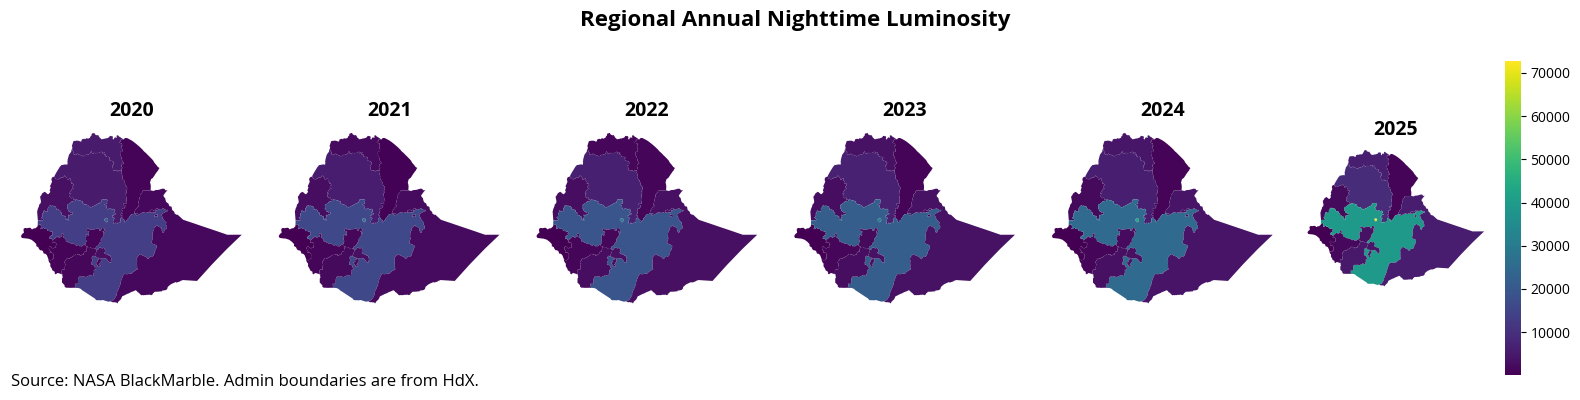

In [83]:
import matplotlib.pyplot as plt
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Define the custom colors
colors = ["#754493", "#A873C4", "#D1AEE3", "#EFEFEF", "#98CBCC", "#4EA2AC", "#24768E"]


# Create the custom colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)

# Define the years to loop through
years = [2020, 2021, 2022, 2023, 2024, 2025]


# Calculate vmin and vmax for consistent color scaling
vmin = ntl_admin1_annual_gdf[ntl_admin1_annual_gdf["date"] > "2019-01-01"][
    "ntl_sum"
].min()
vmax = ntl_admin1_annual_gdf[ntl_admin1_annual_gdf["date"] > "2019-01-01"][
    "ntl_sum"
].max()

# Create subplots
fig, axes = plt.subplots(
    1, 6, figsize=(16, 4), gridspec_kw={"width_ratios": [1, 1, 1, 1, 1, 1]}
)  # 2 rows, 2 columns for 4 subplots
axes = axes.flatten()  # Flatten for easy indexing

for idx, year in enumerate(years):
    # Filter the GeoDataFrame for the given year
    filtered_data = ntl_admin1_annual_gdf[
        ntl_admin1_annual_gdf["date"] == f"{year}-01-01"
    ]

    # Add the legend only to the last plot
    legend = idx == len(years) - 1

    # Plot on the respective subplot
    filtered_data.plot(
        column="ntl_sum",
        ax=axes[idx],
        legend=legend,  # Add legend only for the last plot
        vmin=vmin,
        vmax=vmax,
        cmap="viridis",  # Adjust color map as needed
    )
    axes[idx].set_title(f"{year}", fontsize=14)  # Set title to just the year
    axes[idx].axis("off")

# Add a main title
fig.suptitle("Regional Annual Nighttime Luminosity", fontsize=16, y=0.95, fontweight="bold")

plt.figtext(
    0.01,
    0.01,
    "Source: NASA BlackMarble. Admin boundaries are from HdX.",
    ha="left",
    fontsize=12,
)


# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the main title
plt.show()


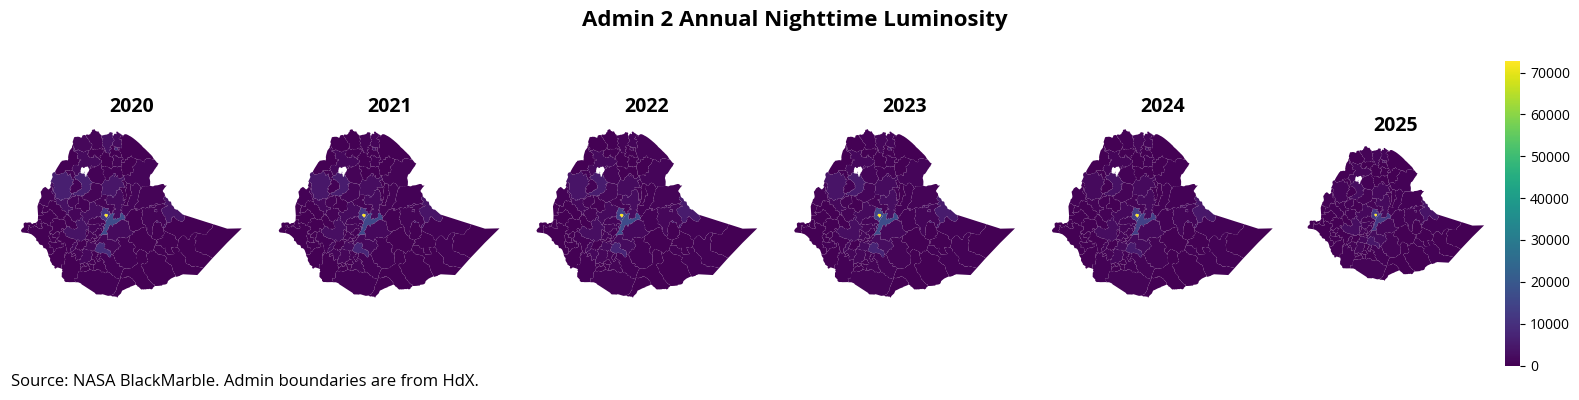

In [81]:
import matplotlib.pyplot as plt
import geopandas as gpd

import matplotlib.colors as mcolors
import numpy as np

# Define the custom colors
colors = ["#754493", "#A873C4", "#D1AEE3", "#EFEFEF", "#98CBCC", "#4EA2AC", "#24768E"]

# Create the custom colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)

# Define the years to loop through
years = [2020, 2021, 2022, 2023, 2024, 2025]

# Calculate vmin and vmax for consistent color scaling
vmin = ntl_admin2_annual_gdf[ntl_admin2_annual_gdf["date"] > "2019-01-01"]["ntl_sum"].min()
vmax_values = ntl_admin2_annual_gdf[ntl_admin2_annual_gdf["date"] > "2019-01-01"].groupby("ADM2_EN")["ntl_sum"].max()

# Sort regions by decreasing vmax
sorted_regions = vmax_values.sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(1, 6, figsize=(16, 4), gridspec_kw={"width_ratios": [1, 1, 1, 1, 1, 1]})
axes = axes.flatten()

for idx, year in enumerate(years):
    # Filter the GeoDataFrame for the given year
    filtered_data = ntl_admin2_annual_gdf[ntl_admin2_annual_gdf["date"] == f"{year}-01-01"]
    # Reorder by sorted_regions
    filtered_data = filtered_data.set_index("ADM2_EN").loc[sorted_regions].reset_index()

    legend = idx == len(years) - 1

    filtered_data.plot(
        column="ntl_sum",
        ax=axes[idx],
        legend=legend,
        vmin=vmin,
        vmax=filtered_data["ntl_sum"].max(),
        cmap="viridis",
    )
    axes[idx].set_title(f"{year}", fontsize=14)
    axes[idx].axis("off")

fig.suptitle("Admin 2 Annual Nighttime Luminosity", fontsize=16, y=0.95, fontweight="bold")
plt.figtext(
    0.01,
    0.01,
    "Source: NASA BlackMarble. Admin boundaries are from HdX.",
    ha="left",
    fontsize=12,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

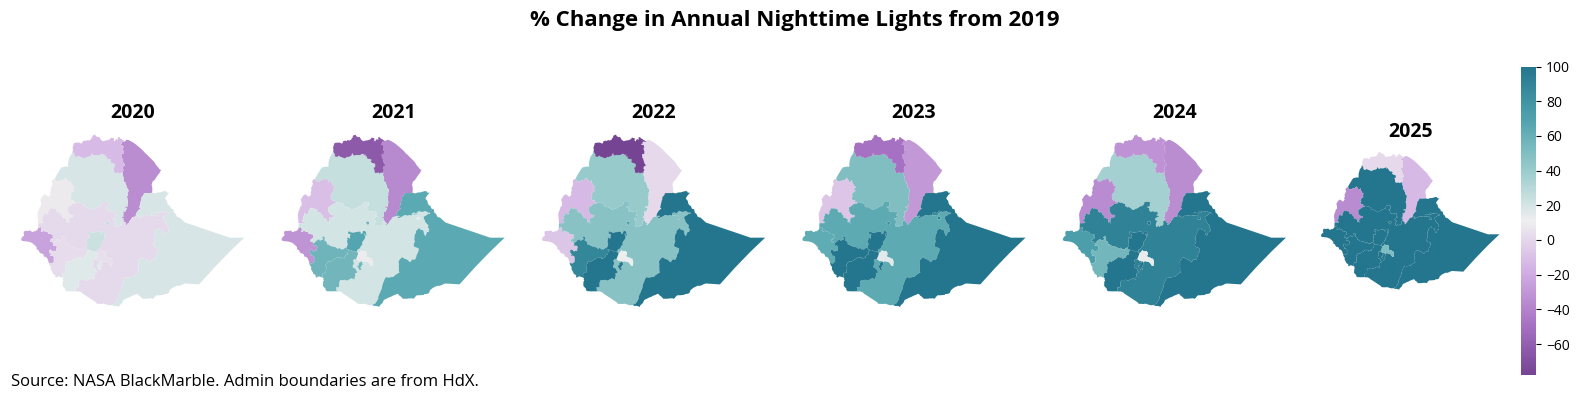

In [80]:
import matplotlib.pyplot as plt
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Define the custom colors
colors = ["#754493", "#A873C4", "#D1AEE3", "#EFEFEF", "#98CBCC", "#4EA2AC", "#24768E"]


# Create the custom colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)

# Define the years to loop through
years = [2020, 2021, 2022, 2023, 2024, 2025]


# Calculate vmin and vmax for consistent color scaling
vmin = ntl_admin1_annual_gdf[ntl_admin1_annual_gdf["date"] > "2019-01-01"][
    "percent_change_ntl_sum_2019"
].min()
vmax = 100  # ntl_admin1_annual_gdf[ntl_admin1_annual_gdf['date']>'2019-01-01']['percent_change'].max()

# Create subplots
fig, axes = plt.subplots(
    1, 6, figsize=(16, 4), gridspec_kw={"width_ratios": [1, 1, 1, 1, 1, 1]}
)  # 2 rows, 2 columns for 4 subplots
axes = axes.flatten()  # Flatten for easy indexing

for idx, year in enumerate(years):
    # Filter the GeoDataFrame for the given year
    filtered_data = ntl_admin1_annual_gdf[
        ntl_admin1_annual_gdf["date"] == f"{year}-01-01"
    ]

    # Add the legend only to the last plot
    legend = idx == len(years) - 1

    # Plot on the respective subplot
    filtered_data.plot(
        column="percent_change_ntl_sum_2019",
        ax=axes[idx],
        legend=legend,  # Add legend only for the last plot
        vmin=vmin,
        vmax=vmax,
        cmap=custom_cmap,  # Adjust color map as needed
    )
    axes[idx].set_title(f"{year}", fontsize=14)  # Set title to just the year
    axes[idx].axis("off")

# Add a main title
fig.suptitle(
    "% Change in Annual Nighttime Lights from 2019",
    fontsize=16,
    y=0.95,
    fontweight="bold",
)

plt.figtext(
    0.01,
    0.01,
    "Source: NASA BlackMarble. Admin boundaries are from HdX.",
    ha="left",
    fontsize=12,
)


# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the main title
plt.show()


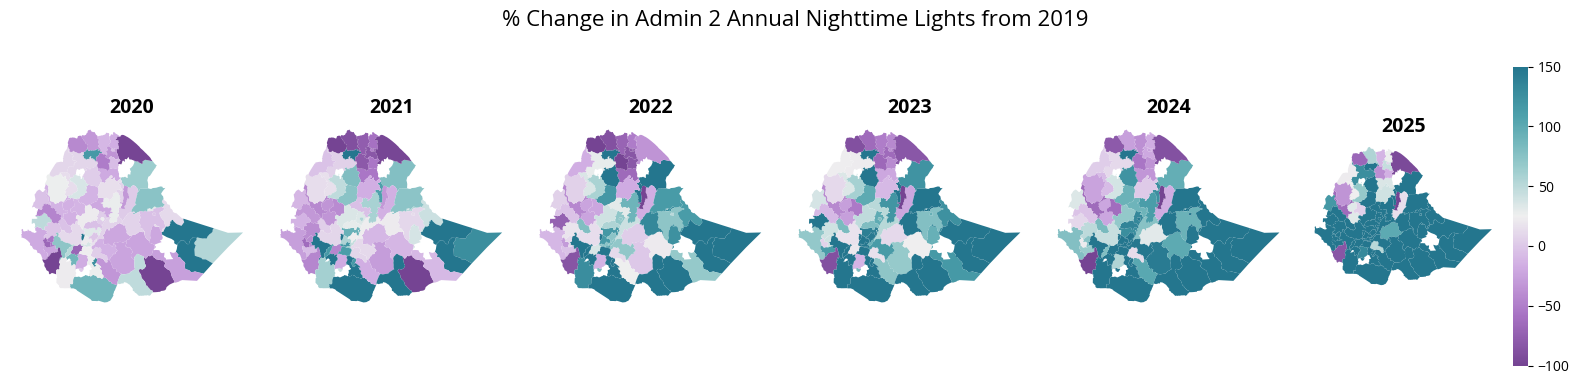

In [79]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Define the years to loop through
years = [2020, 2021, 2022, 2023, 2024, 2025]

# Calculate vmin and vmax for consistent color scaling
vmin = ntl_admin2_annual_gdf[ntl_admin2_annual_gdf["date"] > "2019-01-01"][
    "percent_change_ntl_sum_2019"
].min()
vmax = 150  # ntl_admin2_annual_gdf[ntl_admin2_annual_gdf['date']>'2019-01-01']['percent_change'].max()

# Create subplots
fig, axes = plt.subplots(1, 6, figsize=(16, 4))  # 1 row, 6 columns for 6 subplots
axes = axes.flatten()  # Flatten for easy indexing

for idx, year in enumerate(years):
    # Filter the GeoDataFrame for the given year
    filtered_data = ntl_admin2_annual_gdf[
        ntl_admin2_annual_gdf["date"] == f"{year}-01-01"
    ]

    # Add the legend only to the last plot
    legend = idx == len(years) - 1

    # Plot on the respective subplot
    filtered_data.plot(
        column="percent_change_ntl_sum_2019",
        ax=axes[idx],
        legend=legend,  # Add legend only for the last plot
        vmin=vmin,
        vmax=vmax,
        cmap=custom_cmap,  # Adjust color map as needed
    )
    axes[idx].set_title(f"{year}", fontsize=14)  # Set title to just the year
    axes[idx].axis("off")

# Add a main title
fig.suptitle("% Change in Admin 2 Annual Nighttime Lights from 2019", fontsize=16, y=0.95)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the main title
plt.show()


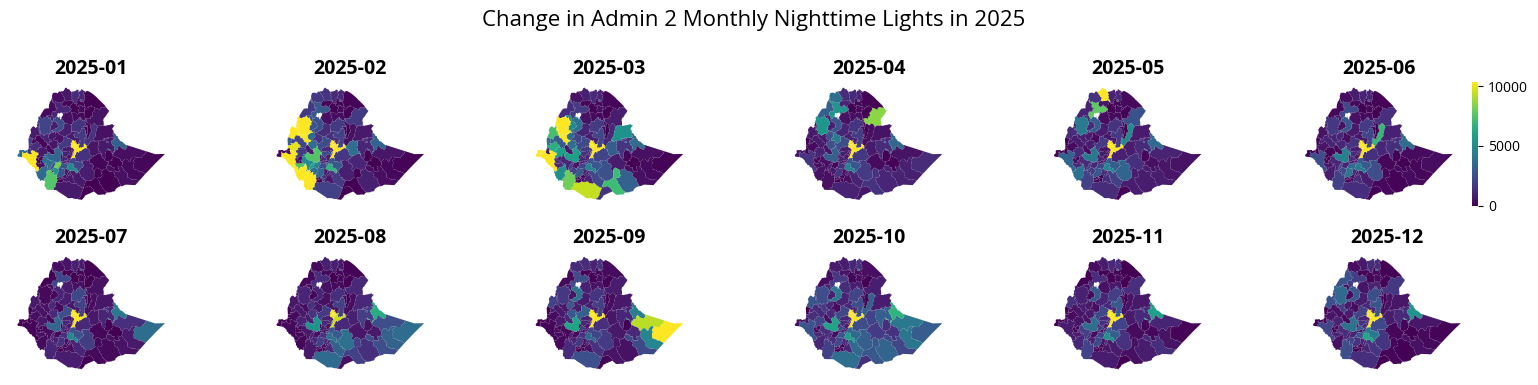

In [82]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Define the years to loop through
months_2024 = (
    pd.date_range("2025-01-01", periods=12, freq="MS").strftime("%Y-%m").tolist()
)


df = ntl_admin2_monthly_gdf.copy()
df = df[(df["date"] > "2023-12-31")]

# Calculate vmin and vmax for consistent color scaling
vmin = df["ntl_sum"].min()
vmax = df["ntl_sum"].max() / 10

# Create subplots
fig, axes = plt.subplots(2, 6, figsize=(16, 4))  # 2 rows, 2 columns for 4 subplots
axes = axes.flatten()  # Flatten for easy indexing

for idx, month in enumerate(months_2024):
    # Filter the GeoDataFrame for the given year
    filtered_data = df[df["date"] == month]

    # Add the legend only to the last plot
    legend = idx == len(years) - 1

    # Plot on the respective subplot
    filtered_data.plot(
        column="ntl_sum",
        ax=axes[idx],
        legend=legend,  # Add legend only for the last plot
        vmin=vmin,
        vmax=vmax,
        cmap="viridis",  # Adjust color map as needed
    )
    axes[idx].set_title(f"{month}", fontsize=14)  # Set title to just the year
    axes[idx].axis("off")

# Add a main title
fig.suptitle("Change in Admin 2 Monthly Nighttime Lights in 2025", fontsize=16, y=0.95)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the main title
plt.show()
